### **Notebook Session - OOF Stacking**

Data: url [Titanic Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic/data)

Very simple OOF stacking example:

- Model 0: Random Forest, Decision Tree, Extra Trees, AdaBoost, GBM
- Model 1: Ridge

In [18]:
# imports
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import RidgeClassifier

#### **Data Import**

In [19]:
df_train = pd.read_csv('./data/titanic/train.csv')
test_df = pd.read_csv('./data/titanic/test.csv')

In [20]:
df_train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [21]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### **Data Cleansing and Feature Engineering**

In [22]:
# Use train and test together, like in the decision-tree notebook
df_train['is_train'] = 1
test_df['is_train'] = 0

all_data = pd.concat([df_train, test_df], axis=0).reset_index(drop=True)
all_data = all_data.drop('Survived', axis=1)

print(f"Combined shape: {all_data.shape}")
print(all_data['is_train'].value_counts())

Combined shape: (1309, 12)
is_train
1    891
0    418
Name: count, dtype: int64


In [23]:
((all_data.isnull().sum()) / len(all_data)) * 100

PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.091673
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.076394
Cabin          77.463713
Embarked        0.152788
is_train        0.000000
dtype: float64

In [24]:
# Keep the same simple features as the starting notebook
all_data = all_data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Fare', 'Embarked'], axis=1)

all_data['Age'] = all_data['Age'].fillna(all_data['Age'].mean())
all_data['Sex'] = all_data['Sex'].map({'male': 1, 'female': 0})

all_data.head()

,Pclass,Sex,Age,SibSp,Parch,is_train
0,3,1,22.0,1,0,1
1,1,0,38.0,1,0,1
2,3,0,26.0,0,0,1
3,1,0,35.0,1,0,1
4,3,1,35.0,0,0,1


In [25]:
X = all_data[all_data['is_train'] == 1].drop('is_train', axis=1)
y = df_train['Survived']

X_final = all_data[all_data['is_train'] == 0].drop('is_train', axis=1)

print(X.shape, y.shape, X_final.shape)

(891, 5) (891,) (418, 5)


#### **Model 0 - Base Models**

In [26]:
base_models = {
    'random_forest': RandomForestClassifier(n_estimators=100, random_state=101),
    'decision_tree': DecisionTreeClassifier(random_state=101),
    'extra_trees': ExtraTreesClassifier(n_estimators=100, random_state=101),
    'adaboost': AdaBoostClassifier(n_estimators=100, random_state=101),
    'gbm': GradientBoostingClassifier(random_state=101)
}

base_models

{'random_forest': RandomForestClassifier(random_state=101),
 'decision_tree': DecisionTreeClassifier(random_state=101),
 'extra_trees': ExtraTreesClassifier(random_state=101),
 'adaboost': AdaBoostClassifier(n_estimators=100, random_state=101),
 'gbm': GradientBoostingClassifier(random_state=101)}

#### **OOF Predictions**

In [27]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)

oof_train = pd.DataFrame(index=X.index)
oof_final = pd.DataFrame(index=X_final.index)
base_scores = {}

for name, model in base_models.items():
    print(f'Training {name}...')
    oof_pred = np.zeros(len(X))
    final_pred = np.zeros(len(X_final))
    fold_scores = []
    
    for train_idx, valid_idx in kf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        
        fold_model = clone(model)
        fold_model.fit(X_train, y_train)
        
        valid_proba = fold_model.predict_proba(X_valid)[:, 1]
        final_proba = fold_model.predict_proba(X_final)[:, 1]
        
        oof_pred[valid_idx] = valid_proba
        final_pred += final_proba / kf.n_splits
        fold_scores.append(accuracy_score(y_valid, valid_proba >= 0.5))
    
    oof_train[name] = oof_pred
    oof_final[name] = final_pred
    base_scores[name] = np.mean(fold_scores)

pd.Series(base_scores).sort_values(ascending=False)

Training random_forest...
Training decision_tree...
Training extra_trees...
Training adaboost...
Training gbm...


gbm              0.814820
adaboost         0.802492
random_forest    0.797979
extra_trees      0.775545
decision_tree    0.773279
dtype: float64

In [28]:
oof_train.head()

,random_forest,decision_tree,extra_trees,adaboost,gbm
0,0.445,0.0,0.39,0.369193,0.070997
1,0.980,1.0,1.00,0.634622,0.953523
2,0.740,1.0,1.00,0.506207,0.534653
3,1.000,1.0,1.00,0.660610,0.971794
4,0.000,0.0,0.00,0.366336,0.113566


#### **Base Model Confusion Matrices**

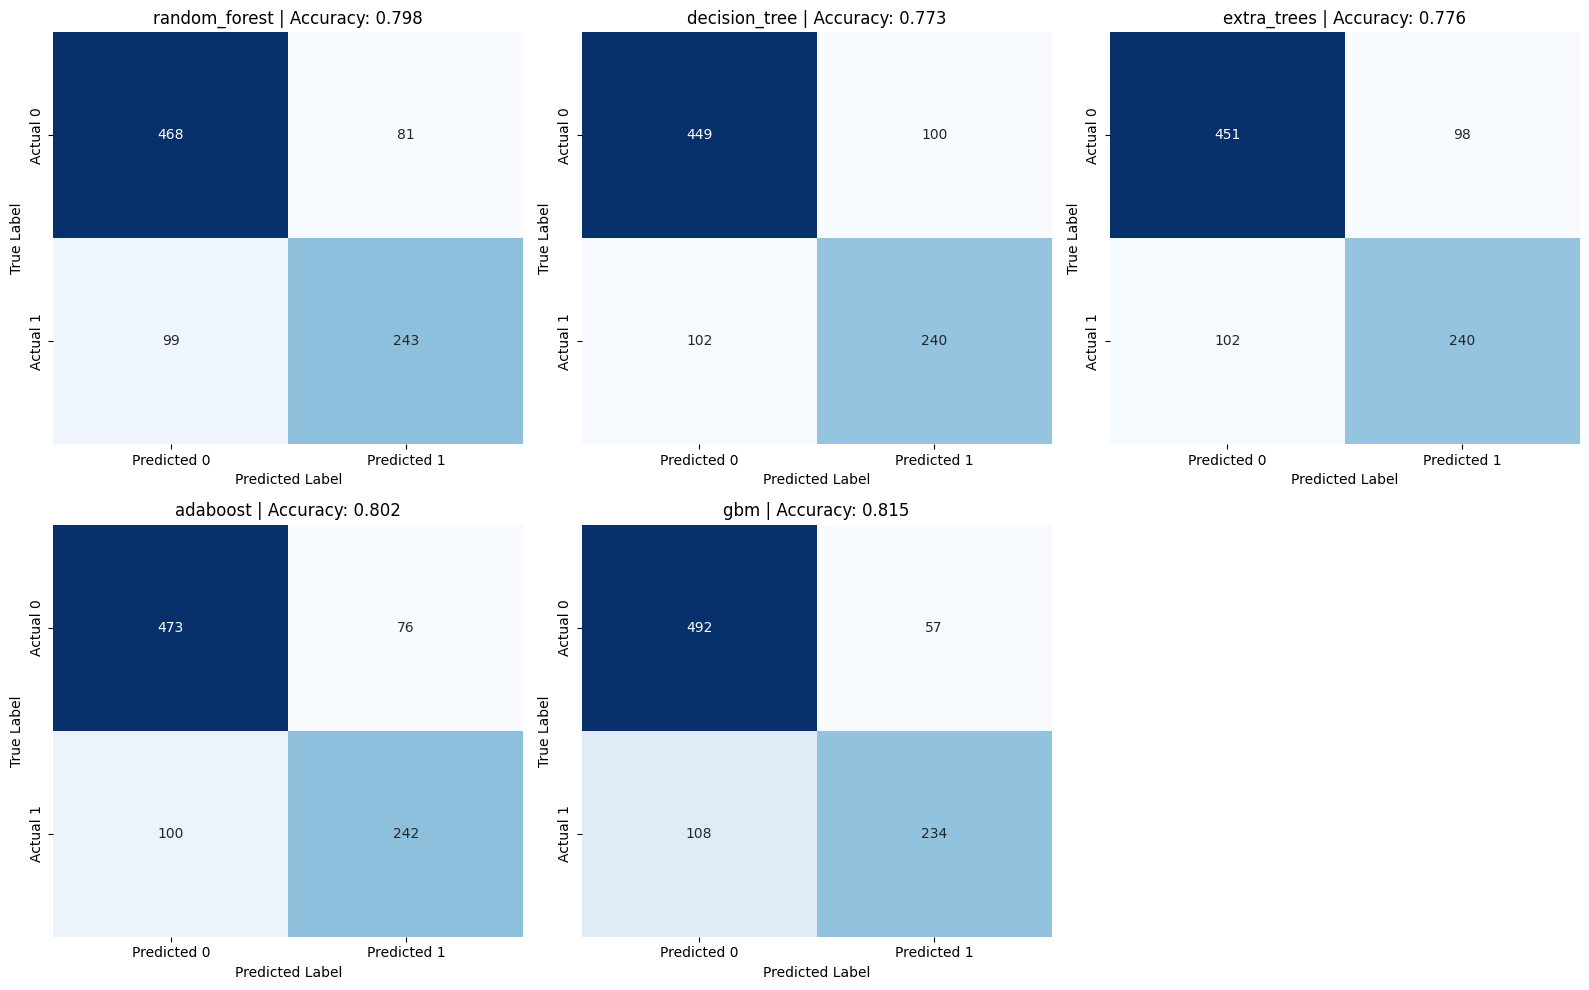

In [29]:
n_cols = 3
n_rows = int(np.ceil(len(oof_train.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for ax, model_name in zip(axes, oof_train.columns):
    model_pred = (oof_train[model_name] >= 0.5).astype(int)
    model_acc = accuracy_score(y, model_pred)
    cm = confusion_matrix(y, model_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'], ax=ax)
    
    ax.set_title(f'{model_name} | Accuracy: {model_acc:.3f}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

for ax in axes[len(oof_train.columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

#### **Model 1 - Ridge**

In [12]:
ridge = RidgeClassifier(alpha=1.0)
ridge_scores = cross_val_score(ridge, oof_train, y, cv=kf, scoring='accuracy')

print('Ridge OOF stacking accuracy:', ridge_scores.mean())

Ridge OOF stacking accuracy: 0.8170673529596385


In [13]:
ridge.fit(oof_train, y)
oof_pred = ridge.predict(oof_train)

print(classification_report(y, oof_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       549
           1       0.80      0.70      0.75       342

    accuracy                           0.82       891
   macro avg       0.81      0.80      0.80       891
weighted avg       0.82      0.82      0.82       891



OOF stacking accuracy: 0.8181818181818182


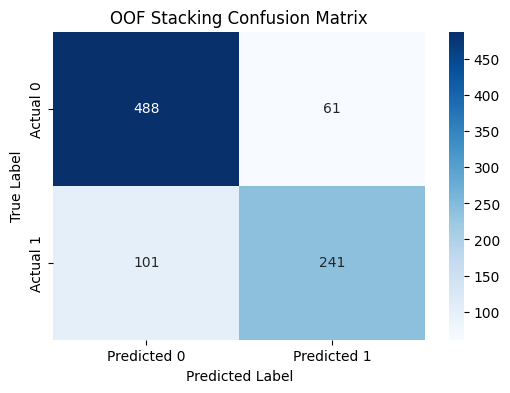

In [14]:
print('OOF stacking accuracy:', accuracy_score(y, oof_pred))

cm = confusion_matrix(y, oof_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('OOF Stacking Confusion Matrix')
plt.show()

#### **Submission**

In [15]:
y_test_pred = ridge.predict(oof_final)

In [16]:
def results_to_csv(y_test, passenger_ids, file_name):
    df = pd.DataFrame({
        'PassengerId': passenger_ids,
        'Survived': y_test.astype(int)
    })
    
    df.to_csv(file_name, index=False)
    print(f'Predictions saved to {file_name}')
    return df

In [17]:
ts = datetime.now().strftime('%Y%m%d%H%M%S')
sub_name = 'submission_stacking_' + ts + '.csv'
passenger_ids = test_df['PassengerId']

submission_df = results_to_csv(y_test_pred, passenger_ids, sub_name)
submission_df.head(10)

Predictions saved to submission_stacking_20260503190722.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0
